# Rare Disease Splicing Practicum Using LeafCutterMD

Welcome to this R-code-based Notebook that will take you through a real world tour of the bioinformatics of outlier splicing detection for rare diseases. An estimated 15 to 60% rare disease-causing variants affect  normal splicing ([ref](https://www.biorxiv.org/content/10.1101/2019.12.18.866830v1.full)).  Furthermore, the causative variants are not always readily detectable as they may affect distal or intronic functional units.  Since the splicing defects causing rare disease must themselves be rare, an approach that characterizes differential splicing between a proband and a cohort unaffected by the same disease is a logical means of defining aberrant splicing.  Such approaches are complicated by the inherently noisy nature of the transcriptome, and thus some means of condensing the data to testable 'units' and applying appropriate statistical testing between a single sample versus many others in a cohort is required.  While various methods exist e.g. FRASER, MAGIQ, we will demonstrate usage of the [LeafcutterMD method](https://academic.oup.com/bioinformatics/article/doi/10.1093/bioinformatics/btaa259/5823301) recently published by our group. Additional details for the method can be found in the previously linked publication, or the corresponding [documentation of the software package](https://davidaknowles.github.io/leafcutter/articles/UsageLeafcutterMD.html).



## Install Dependencies and Load Data

To get started click on the next cell of code and hit shift-enter **or click the play icon in the upper-left corner** to run the code. **_Run this first block of code while listening to the lecture,_** since this will install into your Google Colab environment all the necessary dependencies and load in our example data set. 

We also load a table of results from three relevant clusters (i.e., the aforementioned testable 'units'). To generate this table, we had to align the RNA-seq reads in our `fastq` files using an aligner (e.g., we used `STAR` here) and then convert the `bam` files to `junc` files using LeafCutter's `bam2junc.sh` script, and finally use these junctions to define and cluster the introns using LeafCutter's `leafcutter_cluster.py` script. These are described in greater detail as steps 0-2 on the [LeafCutterMD documentation website](http://davidaknowles.github.io/leafcutter/articles/UsageLeafcutterMD.html).

In [1]:
# install dependencies
system("sudo apt-get -y install libcairo2-dev")
system("sudo apt-get -y install libxt-dev")
system("sudo apt-get -y install gsl-bin")
system("sudo apt-get -y install libgsl0-dev")
install.packages(c("optparse","doMC","BiocManager","R.utils"))
BiocManager::install(c("Biobase","DirichletMultinomial"))
install.packages(c("TailRank","plyr"))

# load libraries and set cores
suppressMessages(library(optparse))
suppressMessages(library(DirichletMultinomial))
suppressMessages(library(TailRank))
suppressMessages(library(doMC))
suppressMessages(library(plyr))
registerDoMC(2) # notebook has 2 cores

# load in anonymized and truncated data
df <- read.table(header=T,sep=" ",quote="'",stringsAsFactors=F,text=
"Proband1 Proband2 Proband3 Proband4 Proband5 Proband6 Proband7 Proband8 Proband9 Proband10 Proband11 Proband12 Proband13 Proband14 Proband15 Proband16 Proband17 Proband18 Proband19 Proband20 Proband21 Proband22 Proband23 Proband24 Proband25 Proband26 Proband27 Proband28 Proband29 Proband30 Proband31 Proband32 Proband33 Proband34 Proband35 Proband36 Proband37 Proband38 Proband39 Proband40 Proband41 Proband42 Proband43 Proband44 Proband45 Proband46 Proband47 Proband48 Proband49 Proband50 Proband51 Proband52 Proband53 Proband54 Proband55 Proband56 Proband57 Proband58 Proband59 Proband60 Proband61 Proband62 Proband63 Proband64 Proband65 Proband66 Proband67 Proband68 Proband69 Proband70 Proband71 Proband72 Proband73 Proband74 Proband75 Proband76 Proband77 Proband78 Proband79 Proband80 Proband81 Proband82 Proband83 Proband84 Proband85 Proband86 Proband87 Proband88 Proband89 Proband90 Proband91 Proband92 Proband93 Proband94 Proband95 Proband96 Proband97 Proband98 Proband99 Proband100 Proband101 Proband102 Proband103 Proband104 Proband105 Proband106 Proband107 Proband108 Proband109 Proband110 Proband111 Proband112 Proband113 Proband114 Proband115 Proband116 Proband117 Proband118 Proband119 Proband120 Proband121 Proband122 Proband123 Proband124 Proband125 Proband126 Proband127 Proband128
1:245023776:245025763:clu_30973_NA 710 728 1207 927 1004 804 435 1026 1363 2389 787 651 459 507 1162 808 687 910 834 1187 83 1015 934 1369 934 1723 999 744 768 1419 1232 1103 782 847 1286 786 263 733 1615 351 1174 1476 871 457 1541 881 1027 1267 1185 918 377 440 1644 1035 603 265 1013 655 615 1196 1357 1490 1597 1186 524 1095 341 723 1776 962 708 871 1750 693 1028 1024 620 892 991 1597 586 1251 2312 748 1080 1104 1129 1478 735 1452 599 1014 1753 534 688 437 654 278 1536 351 928 651 1205 2430 560 468 352 957 861 790 997 341 800 839 1486 549 1024 569 1265 965 1034 829 340 473 869 2100 794 636
1:245023776:245026919:clu_30973_NA 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 18 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
1:245023776:245026976:clu_30973_NA 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 61 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
1:245025836:245025921:clu_30973_NA 792 723 1056 1098 1184 847 492 1028 1475 2739 898 711 490 543 1299 856 734 755 955 1209 93 1094 1041 1499 892 1501 1027 841 859 1377 1426 1135 937 880 1448 749 351 894 1411 323 1259 1494 975 448 1494 881 1060 1426 1148 898 411 493 1665 1052 626 219 1057 776 865 1223 1301 1633 1636 1231 497 1226 444 884 1707 977 828 982 1783 730 1091 1114 724 1050 976 1603 695 1275 2001 718 1164 1096 1072 1650 849 1132 689 1275 1831 565 678 534 770 320 1532 355 987 777 1359 2357 530 484 353 1091 901 717 958 319 815 873 1431 664 1053 558 1339 1219 1217 922 462 543 895 1844 976 740
1:245025836:245026919:clu_30973_NA 3 0 1 0 0 0 1 0 2 0 0 3 0 0 0 0 0 6 3 14 0 0 2 2 0 0 0 0 0 5 0 0 0 0 0 0 0 2 0 0 2 0 1 0 1 0 3 1 0 0 0 0 0 0 0 0 0 0 2 7 8 3 0 0 0 1 0 0 7 0 2 1 10 0 10 1 0 0 0 5 0 16 5 0 0 0 1 4 0 0 0 0 5 1 0 0 0 0 1 0 0 0 1 1 3 0 0 0 0 0 0 0 0 2 3 0 0 0 0 0 0 0 0 0 0 2 0 0
1:245025836:245026976:clu_30973_NA 1 2 2 0 0 3 0 0 12 6 1 2 3 7 3 0 2 5 0 0 0 3 0 16 2 14 14 1 4 0 0 6 3 8 0 2 0 2 0 0 5 2 0 1 9 0 7 2 3 6 0 2 0 2 5 0 0 0 0 7 12 12 0 2 4 0 0 1 5 4 2 1 9 0 4 5 2 0 3 13 0 0 14 2 0 0 8 1 13 0 2 0 13 10 2 0 2 0 11 0 0 4 5 10 0 0 1 2 1 1 2 1 0 1 9 0 0 0 7 4 5 0 2 2 5 3 3 8
1:245026032:245026919:clu_30973_NA 36 195 233 41 57 65 39 34 373 460 43 103 36 40 228 123 55 160 62 184 25 225 55 351 164 282 278 32 138 242 297 239 91 120 59 144 28 88 66 77 181 79 175 30 327 53 175 68 56 166 74 18 257 59 52 13 123 37 90 219 208 340 231 55 135 128 26 55 307 152 122 141 425 41 168 64 40 80 231 304 53 213 392 148 88 69 101 321 172 43 65 86 402 106 33 28 61 38 264 66 56 60 219 437 93 28 45 79 45 184 39 33 55 60 195 45 75 43 394 72 173 61 65 52 65 330 109 90
1:245026032:245026976:clu_30973_NA 104 382 329 79 132 104 40 146 492 1074 109 228 83 91 374 250 109 221 89 276 24 285 131 604 269 549 351 94 327 380 388 407 126 342 124 267 33 111 82 88 344 144 211 79 532 115 288 177 132 270 64 62 504 289 93 33 206 84 75 269 246 532 395 153 144 187 44 134 441 274 219 344 536 66 229 157 116 121 324 619 100 293 645 297 157 97 128 505 317 83 114 106 682 135 95 67 113 55 579 70 103 125 274 758 112 40 33 202 97 249 84 63 79 101 417 102 90 78 411 108 354 81 122 90 150 561 117 118
7:92132509:92134020:clu_9890_NA 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
7:92132509:92134046:clu_9890_NA 41 15 27 59 37 65 24 23 29 170 46 9 27 25 35 29 25 16 65 48 8 13 36 60 22 56 31 17 15 21 14 28 61 21 58 18 4 17 18 25 57 52 51 5 52 30 27 29 32 25 17 19 41 55 24 5 32 12 16 40 52 35 86 66 22 40 17 38 38 24 10 16 19 16 14 44 55 41 31 29 17 55 78 27 51 49 38 35 18 56 46 53 51 36 35 28 32 16 58 18 37 47 36 69 9 25 3 41 54 23 30 20 35 49 82 43 57 16 55 65 80 40 36 29 52 41 28 32
7:92132509:92135562:clu_9890_NA 0 0 0 1 5 1 0 0 1 0 0 0 0 0 0 0 0 0 0 14 0 0 0 15 5 3 0 0 0 0 0 0 0 1 0 0 4 1 0 0 0 0 0 1 0 0 0 3 4 2 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 1 0 1 0 0 0 3 0 1 0 7 0 3 3 0 0 0 0 0 0 0 0 4 0 0 1 0 0 0 2 0 0 0 3 0 2 0 0 3 0
7:92132536:92134046:clu_9890_NA 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 10 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
7:92134216:92135562:clu_9890_NA 114 103 126 121 89 136 59 83 130 454 89 79 88 47 4 126 110 76 190 164 15 78 99 199 136 211 65 122 53 157 206 229 156 136 206 140 47 35 127 50 138 144 153 29 209 107 106 194 171 49 48 60 278 116 74 19 40 81 96 132 104 223 145 120 66 165 51 121 150 141 79 171 141 63 92 128 172 138 90 190 69 140 155 112 117 247 111 203 157 119 119 144 487 80 52 32 95 31 219 60 82 123 183 187 28 79 48 124 120 84 137 46 73 89 351 90 139 77 177 146 163 77 68 64 96 181 56 105
7:92134216:92136308:clu_9890_NA 0 0 0 0 0 0 0 0 0 0 0 0 0 0 39 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
7:92135653:92136308:clu_9890_NA 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 11 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
7:92135658:92136077:clu_9890_NA 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
7:92135658:92136295:clu_9890_NA 0 0 0 0 0 1 0 0 0 0 0 0 8 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 14 0 0 0 0 0 0 0 0 9 0 0 0 0 0 0 0 0 12 0 0 0 0 0 1 0 0 0 0 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 6 0 0 0 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
7:92135658:92136308:clu_9890_NA 111 45 241 56 60 108 55 96 204 334 136 75 57 107 17 166 86 57 72 208 13 97 103 200 88 168 119 63 95 146 172 241 84 120 180 107 61 70 142 95 102 125 121 24 193 84 137 209 77 83 30 71 353 136 28 30 72 84 111 133 118 178 235 155 62 140 60 89 239 138 86 164 129 29 154 70 97 90 100 200 75 289 197 48 94 131 83 192 143 172 115 65 324 45 50 24 133 33 350 70 89 120 128 310 63 65 42 82 115 65 175 73 75 127 292 99 140 62 145 124 333 59 42 40 96 175 122 111
7:92135672:92136308:clu_9890_NA 0 0 1 0 0 0 0 0 0 13 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 7 0 4 0 1 0 0 0 0 3 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 4 0 2 0 5 0 0 0 0 0 0 0 0 0 0 0 0 9 0 0 0 0 0 0 0 0 0 0 0
7:92136130:92136308:clu_9890_NA 0 1 13 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 1 0 0 0 0 0 0 0 0 0 0 5 0 0 2 0 0 0 0 0 0 0 0 0 0 0
22:41553412:41554380:clu_23997_NA 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 16 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
22:41553412:41554416:clu_23997_NA 655 611 580 1038 658 486 328 1018 1113 1171 592 411 407 304 502 393 285 624 547 465 108 1016 648 882 554 996 792 473 282 552 1267 871 524 399 1058 353 325 478 1178 165 521 1402 640 197 879 610 569 693 1155 515 338 475 1001 474 486 253 893 538 766 1073 776 877 756 866 389 863 425 395 1220 497 390 367 738 718 816 1063 484 1076 862 1129 536 624 1653 312 876 1031 794 1035 320 482 360 949 603 426 619 334 495 199 744 386 645 446 869 1486 879 223 164 725 516 467 472 271 571 520 659 235 756 517 536 783 593 925 316 309 599 1371 460 416
22:41553412:41556646:clu_23997_NA 0 2 0 2 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0
22:41553412:41560057:clu_23997_NA 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 13 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 18 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
22:41554504:41555700:clu_23997_NA 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 4 0 0 0 0 0 0 0 6 0 0 0 0 0 0
22:41554504:41555704:clu_23997_NA 0 3 0 6 0 0 0 4 7 0 4 0 0 0 1 0 0 0 7 0 0 4 0 0 2 0 1 0 0 0 0 0 0 12 1 2 1 0 1 0 2 1 0 0 0 0 0 0 0 6 0 0 3 0 0 0 0 2 2 1 0 13 7 0 1 1 0 0 0 0 0 0 3 9 0 18 1 0 2 0 0 0 27 0 0 9 0 0 2 0 1 3 9 0 10 0 0 0 0 0 9 0 0 0 7 0 0 11 4 0 0 0 3 0 0 0 0 5 0 0 0 0 0 3 0 0 0 0
22:41554504:41556616:clu_23997_NA 0 2 0 2 0 0 0 0 0 0 0 0 7 0 0 0 0 5 4 0 0 0 0 14 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 4 0 0 0 0 5 0 1 0 4 0 41 0 0 0 0 0 0 0 16 0 0 0 11 0 0 0 0 0 2 0 0 0 6 0 0 0 10 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 4 10 0 0 13 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0
22:41554504:41556646:clu_23997_NA 660 650 670 1083 632 467 334 991 1034 818 514 381 333 322 410 326 320 611 606 506 79 1065 538 806 503 1102 705 452 308 780 1164 660 486 499 1217 371 289 436 1175 165 530 1329 479 289 867 710 523 704 1151 520 321 475 845 555 514 263 852 566 693 881 1081 1115 659 1044 337 963 471 352 939 497 424 341 872 698 816 1125 453 1105 806 910 567 765 2014 327 807 868 960 972 312 666 396 956 610 428 603 367 536 246 829 375 606 409 1045 1374 987 267 182 994 596 485 561 291 493 557 787 234 848 558 545 803 528 974 284 370 749 1624 633 467
22:41554504:41558727:clu_23997_NA 0 0 0 0 3 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 4
22:41554504:41560057:clu_23997_NA 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 3 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1
22:41555821:41556646:clu_23997_NA 0 0 0 2 4 1 0 0 8 0 0 0 0 4 5 0 0 0 11 0 0 3 0 2 0 0 0 7 0 0 13 0 0 0 5 2 0 0 0 0 0 2 0 0 0 3 0 2 0 0 0 0 0 7 0 0 0 0 0 0 6 1 0 0 2 0 0 0 10 4 4 0 0 2 0 7 0 3 0 0 0 0 7 0 0 12 0 0 1 0 7 0 0 0 0 0 0 0 0 0 13 0 0 0 0 0 1 0 5 0 1 0 0 0 0 2 7 2 0 0 0 0 0 0 2 0 7 0
22:41556726:41558727:clu_23997_NA 719 739 835 1246 802 575 412 1240 1265 1361 683 527 580 388 571 585 417 824 772 719 142 1274 799 1011 669 1236 853 559 424 1072 1395 1079 702 609 1646 402 369 609 1415 213 639 1874 777 298 1106 919 908 967 1578 693 341 549 1429 765 769 281 1253 693 989 977 1415 1404 1096 1294 443 1212 573 454 1404 674 375 479 1306 1056 821 1399 660 1319 971 1481 654 1012 2937 379 1036 1234 1458 1141 485 785 456 1101 898 556 836 432 586 477 859 481 684 579 1231 1842 1232 193 225 1114 760 598 586 283 606 797 879 287 1115 628 921 919 725 1206 371 352 916 2121 939 441
22:41556726:41564453:clu_23997_NA 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
22:41558783:41560057:clu_23997_NA 888 902 996 1669 1059 617 442 1293 1645 1823 827 713 604 513 930 680 501 1042 887 861 127 1578 800 1304 842 1639 1091 647 410 1252 1657 1490 770 701 1849 481 331 568 1523 271 845 2164 847 366 1454 845 988 1098 1604 755 425 594 1685 618 816 355 1295 867 1030 1630 1412 1693 1222 1181 501 1212 571 553 1847 675 725 720 1715 1206 1131 1764 773 1661 1431 1941 712 1498 3153 433 1230 1437 1402 1602 561 1049 586 1351 1191 602 926 503 663 414 1267 524 859 718 1530 2581 1329 292 243 1067 874 677 726 340 751 866 1376 393 985 762 1112 1035 999 1400 405 456 889 2464 981 600
22:41558783:41560074:clu_23997_NA 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 12 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
22:41558783:41562603:clu_23997_NA 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 13 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
22:41558787:41560057:clu_23997_NA 0 0 0 0 4 0 0 0 1 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 11 0 0 0 0 0 0 0 1 0 0 0 0 0
22:41560134:41562586:clu_23997_NA 0 0 0 0 0 0 0 0 9 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
22:41560134:41562603:clu_23997_NA 1072 1247 1311 1838 1226 742 474 1646 2036 2242 907 887 644 635 1124 699 559 1313 1131 1104 145 1942 834 1604 1128 2135 1587 721 634 1744 2093 1794 732 879 1891 694 428 651 1968 385 960 2314 1065 380 1827 768 1043 1217 1915 1194 447 729 2039 756 842 476 1296 1022 1142 2089 1799 2131 1748 1401 602 1543 683 690 2259 910 794 792 1987 1201 1351 1697 791 1926 1696 2487 998 1529 3683 677 1482 1569 1398 2100 680 1207 824 1628 1555 746 1080 743 822 380 1560 631 1062 814 2157 3123 1517 395 367 1274 985 891 924 430 916 1014 1872 433 1221 929 1406 1275 1414 1295 553 619 845 3351 1133 697
22:41560134:41564453:clu_23997_NA 0 5 0 6 6 0 6 0 5 0 4 0 1 3 5 11 0 26 0 0 0 7 0 4 13 13 2 2 0 15 11 0 5 0 26 0 0 7 0 0 10 12 17 0 7 7 23 13 44 0 7 10 9 0 6 0 10 0 10 7 3 6 2 0 1 4 1 0 15 14 0 2 4 5 5 5 4 0 5 20 5 0 8 2 0 0 5 4 4 0 0 0 20 2 2 5 13 7 19 3 12 1 4 17 17 0 0 2 3 3 8 3 0 8 6 0 6 0 0 0 0 0 3 8 0 21 31 2
22:41562669:41564453:clu_23997_NA 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 2 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
22:41562670:41563237:clu_23997_NA 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 1 0 2 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
22:41562670:41564453:clu_23997_NA 647 615 669 1211 764 497 400 1500 1078 983 618 421 408 382 534 542 404 610 821 569 79 1206 618 954 523 1052 652 552 571 1079 1246 953 665 362 1347 361 342 491 1141 240 489 1463 600 269 983 614 636 805 1289 667 279 393 1043 467 479 266 779 715 742 1262 792 1127 868 887 370 847 465 383 1401 407 364 348 1154 761 813 1076 487 1204 987 1152 646 825 1831 357 975 1247 806 1286 363 643 434 1212 795 487 759 401 624 297 757 472 737 470 1035 1461 805 228 251 878 563 550 589 287 621 750 1007 246 796 619 644 994 611 918 313 410 657 2197 605 425
22:41562670:41564725:clu_23997_NA 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 8 0 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0
22:41563388:41564453:clu_23997_NA 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 1 0 0 0 0 0 3 0 0 0 0 3 0 0 0 0 9 0 0 0 0 0 0 0 0 0 0 0 2 0 0 4 0 0 0 0 0 0 3 0 1 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
22:41564603:41564679:clu_23997_NA 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 6 0 0 0 0 0 0 0 11 0 0 0 0 0 0 0 0 1 0 0 0 3 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 1 0 0 0 0 0 0 0 0 3 0
22:41564603:41564717:clu_23997_NA 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 60 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
22:41564603:41564725:clu_23997_NA 868 1071 1048 1778 1096 589 617 1587 1857 1723 1005 679 613 539 994 635 570 880 1095 680 146 1872 935 1545 939 1735 1161 749 652 1416 1805 1262 871 831 1966 556 497 730 1713 302 890 2462 1053 377 1508 866 906 1356 1908 1115 370 728 1978 702 810 478 1572 923 1016 1960 1257 1615 1328 1271 527 1522 723 649 2026 734 732 778 1681 1210 1296 1900 676 1929 1630 1614 1018 1128 2758 539 1411 1419 1413 1749 586 617 722 1753 1388 677 1013 613 797 353 1188 653 1013 819 1585 2743 1487 396 365 1231 837 809 881 497 872 1240 1335 458 1187 916 1152 1249 989 1385 445 609 860 2756 1007 647
")
print("done installing")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘getopt’, ‘foreach’, ‘iterators’, ‘R.oo’, ‘R.methodsS3’


'getOption("repos")' replaces Bioconductor standard repositories, see
'?repositories' for details

replacement repositories:
    CRAN: https://cran.rstudio.com


Bioconductor version 3.13 (BiocManager 1.30.16), R 4.1.0 (2021-05-18)

Installing package(s) 'BiocVersion', 'Biobase', 'DirichletMultinomial'

also installing the dependencies ‘BiocGenerics’, ‘S4Vectors’, ‘IRanges’


Old packages: 'broom', 'dplyr', 'ggplot2', 'openssl', 'rmarkdown', 'testthat',
  'xfun'

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘oompaBase’, ‘oompaData’




[1] "done installing"


## Let's examine the data

We will print the number of rows, number of columns, and glimpse the first six rows of the table.

Then we will convert the `data.frame` object to a `matrix` since the entries are all of type `integer`.

In [2]:
print(nrow(df))
print(ncol(df))
head(df)
counts <- as.matrix(df)

[1] 48
[1] 128


,Proband1,Proband2,Proband3,Proband4,Proband5,Proband6,Proband7,Proband8,Proband9,Proband10,⋯,Proband119,Proband120,Proband121,Proband122,Proband123,Proband124,Proband125,Proband126,Proband127,Proband128
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1:245023776:245025763:clu_30973_NA,710,728,1207,927,1004,804,435,1026,1363,2389,⋯,1265,965,1034,829,340,473,869,2100,794,636
1:245023776:245026919:clu_30973_NA,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
1:245023776:245026976:clu_30973_NA,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
1:245025836:245025921:clu_30973_NA,792,723,1056,1098,1184,847,492,1028,1475,2739,⋯,1339,1219,1217,922,462,543,895,1844,976,740
1:245025836:245026919:clu_30973_NA,3,0,1,0,0,0,1,0,2,0,⋯,0,0,0,0,0,0,0,2,0,0
1:245025836:245026976:clu_30973_NA,1,2,2,0,0,3,0,0,12,6,⋯,7,4,5,0,2,2,5,3,3,8


We can that these data have 128 columns representing disease-affected probands and 48 rows that are introns organized into overlapping clusters by the LeafCutter software package. The entries in the (i,j)-th position of this table are the counts of intron i in proband j. 
The intron name field is colon separated and contains the chromosome, start base pair, end base pair, and clusterID of the intron. In general, this table should contain tens of thousands of introns, but for convenience we have truncated it to contain only three distinct intron clusters. Each of these clusters is representative of aberrant, pathogenic splicing in a single proband.  


## Pull in relevant LeafCutterMD code

In general, you will use this R code from the unix command line as described in step 3 on the [LeafCutterMD documentation website](http://davidaknowles.github.io/leafcutter/articles/UsageLeafcutterMD.html). But for demonstration purposes we are going to peak under the hood a bit to see what the code is doing and how you can examine the results it produces in greater detail. The next block of code contains some functions borrowed from the [LeafCutterMD.R script](https://github.com/davidaknowles/leafcutter/blob/master/scripts/leafcutterMD.R). The only modification below is in the `writeResToFile` function where we set `verboseOutput` to `TRUE` so we can dive a little deeper into the results.

While the code itself is not complicated, it is nonetheless relatively verbose and so we will avoid lengthy examination of the following code block during the practicum. After loading the functions, we use `ls` to show that they have been loaded into our `R` session and are available for use.

In [3]:
#
# Define all the functions for processing:
#
combineClusterPvals <- function(pVals){
    pVals <- as.numeric(pVals)
    return(pbeta(min(pVals),1,length(pVals),lower.tail = TRUE))
}

computeRightPvalBB <- function(count,totalCount,alpha,beta){
  #compute P(X>=count) = 1-P(X<=[count-1])
  if(count>0){
    val <- 1-pbb(count-1,totalCount,alpha,beta)
  }else{
    val <- 1
  }
  
  #fix numerical precision
  val <- max(.Machine$double.eps,min(val,1-.Machine$double.eps))
  return(val)
}


computeLeftPvalBB <- function(count,totalCount,alpha,beta){
  #compute P(X<=count) 
  val <- pbb(count,totalCount,alpha,beta)
  
  #fix numerical precision
  val <- max(.Machine$double.eps,min(val,1-.Machine$double.eps))
  return(val)
}

compute_effectSize_Pvalue <- function(count,totalCount,alphaEst,index,sumAlphaEst,clustMean){
  pRight <- computeRightPvalBB(count,totalCount,alphaEst[index],sumAlphaEst-alphaEst[index])
  pLeft <- computeLeftPvalBB(count,totalCount,alphaEst[index],sumAlphaEst-alphaEst[index])
  pVal <- min(1,2*min(pRight,pLeft))
  
  testVal <- (count/totalCount)
  effectSize <- testVal - clustMean[index]
  
  return(c(pVal=pVal,effectSize=effectSize,testVal=testVal))
}


runOutlierAnalysisCluster <- function(dataMat,alphaEst){
  #find cluster name
  cluID <- strsplit(colnames(dataMat)[1],":")[[1]][4]

  # initialize space
  effectSizesMat <- dataMat
  pValsMat <- dataMat
  testMat  <- dataMat
  
  # compute cluster summaries
  sumAlphaEst <- sum(alphaEst)
  clustMean <- alphaEst/sumAlphaEst
  
  # fill in matrices
  for(sample in seq_along(rownames(dataMat))){
    totalCount <- sum(dataMat[sample,])
    for(junction in seq_along(colnames(dataMat))){
      val <- compute_effectSize_Pvalue(dataMat[sample,junction],totalCount,alphaEst,junction,sumAlphaEst,clustMean)
      effectSizesMat[sample,junction] <- val["effectSize"]
      pValsMat[sample,junction] <- val["pVal"]
      testMat[sample,junction] <- val["testVal"]
    }
  }

  # compute combined pValue for the cluster
  combinedClustPval <- as.data.frame(apply(pValsMat,1,combineClusterPvals))
  colnames(combinedClustPval) <- cluID
  return(list(effectSizesMat=effectSizesMat,pValsMat=pValsMat,combinedClustPval=combinedClustPval,
              clustMean=clustMean,testMat=testMat))
}


# Perform clusterwise splicing analysis.
processCluster <- function(dataMat){
  #do laplace smoothing
  dataMat <- dataMat+1
  
  # model cluster
  dm_fit <- DirichletMultinomial::dmn(dataMat,1)
  
  # get results
  res <- runOutlierAnalysisCluster(dataMat,dm_fit@fit$Estimate)
}

writeResToFile <- function(results,output_prefix,verboseOutput=T){

  # print out first set with headers
  write.table( t(results[[1]]$pValsMat), 
               paste0(output_prefix,"_pVals.txt"), quote=F, col.names = T, row.names = T, sep="\t")
  write.table( t(results[[1]]$effectSizesMat), 
               paste0(output_prefix,"_effSize.txt"), quote=F, col.names = T, row.names = T, sep="\t")
  write.table( t(results[[1]]$combinedClustPval), 
               paste0(output_prefix,"_clusterPvals.txt"), quote=F, col.names = T, row.names = T, sep="\t")
  if(verboseOutput){
    write.table( results[[1]]$clustMean, 
                 paste0(output_prefix,"_controlMean.txt"), quote=F, col.names = F, row.names = T, sep="\t")
    write.table( t(results[[1]]$testMat), 
                 paste0(output_prefix,"_test.txt"), quote=F, col.names = T, row.names = T, sep="\t")
  }
  
  # append rest without headers
  for (index in setdiff(seq_along(results),1)){
    write.table( t(results[[index]]$pValsMat), 
                 paste0(output_prefix,"_pVals.txt"), quote=F, col.names = F, row.names = T, sep="\t", append = T)
    write.table( t(results[[index]]$effectSizesMat), 
                 paste0(output_prefix,"_effSize.txt"), quote=F, col.names = F, row.names = T, sep="\t", append = T)
    write.table( t(results[[index]]$combinedClustPval), 
                 paste0(output_prefix,"_clusterPvals.txt"), quote=F, col.names = F, row.names = T, sep="\t", append = T)
    if(verboseOutput){
      write.table( results[[index]]$clustMean, 
                   paste0(output_prefix,"_controlMean.txt"), quote=F, col.names = F, row.names = T, sep="\t", append = T)
      write.table( t(results[[index]]$testMat), 
                   paste0(output_prefix,"_test.txt"), quote=F, col.names = F, row.names = T, sep="\t", append = T)
    }
  }
}


# Perform outlier splicing analysis.
processAllClusters <- function(counts,output_prefix="leafcutter_outlier",max_cluster_size=30,min_coverage=20,timeout=10){
                              
  #Analyze cluster names
  splitIntrons <- do.call(rbind,strsplit(rownames(counts),":"))
  cluster_ids <- paste(splitIntrons[,1],splitIntrons[,4],sep = ":")
  cluster_sizes <- as.data.frame(table(cluster_ids))
  clu_names <- as.character(cluster_sizes$cluster_ids)
  cluster_sizes <- cluster_sizes$Freq
  names(cluster_sizes) <- clu_names
  
  results <- foreach (cluster_name=clu_names, .errorhandling = "remove") %dopar% {
    # filter out clusters
    if (cluster_sizes[cluster_name] > max_cluster_size)
      stop("Too many introns in cluster")
    junctions_in_cluster=which(cluster_ids==cluster_name)
    if (length(junctions_in_cluster) <= 1)
      stop("<=1 junction in cluster")
    cluster_counts <- t(counts[ junctions_in_cluster, ])
    sample_totals <- rowSums(cluster_counts)
    if (sum(sample_totals>=min_coverage)<=1)
      stop("<=1 sample with coverage>min_coverage")
    
    # process clusters that past filtering
    res <- R.utils::withTimeout( {
      processCluster(cluster_counts)
    }, timeout=timeout, onTimeout="error" )
    res$cluster_name <- cluster_name
    
    res
  } # end foreach
  
  writeResToFile(results,output_prefix)
  
  results
}

# print the variables in our environment to show the functions are now loaded:
ls()

[1] "combineClusterPvals"       "compute_effectSize_Pvalue"
 [3] "computeLeftPvalBB"         "computeRightPvalBB"       
 [5] "counts"                    "df"                       
 [7] "processAllClusters"        "processCluster"           
 [9] "runOutlierAnalysisCluster" "writeResToFile"

## Run LeafCutterMD on our cohort

The `processAllClusters` function is the main workhorse of the LeafCutterMD package, which (in parallel) processes each cluster using the Dirichlet-Multinomial Model and computes p-values for each intron using the corresponding Beta-Binomial Marginal Distribution's tail probabilities. The calculated p-values can provide a measure of statistical confidence that the aberrance of the intron usage for the tested individual versus the rest of the cohort is not due to chance.

All results of this function are written to disk. So to continue exploring our results, we will read in some of these results from the disk into our R session.

In [4]:
# how to run the code on our counts table
results <- processAllClusters(counts)

# these are meant for a command line, so results written to files.
# load some of the results back into our R session:
df_clusterP <- read.table(file="leafcutter_outlier_clusterPvals.txt")
df_intronP <- read.table(file="leafcutter_outlier_pVals.txt")
df_mean <- read.table(file="leafcutter_outlier_controlMean.txt",
                      col.names = c("intron","mean"))
df_test <- read.table(file="leafcutter_outlier_test.txt")
df_effSize <- read.table(file="leafcutter_outlier_effSize.txt")
print("done modeling and loading results")

[1] "done modeling and loading results"


---

##CHECKPOINT 1

---

Let's examine the p-values. Note that these are un-adjusted p-values, which are appropriate for use when you have a specific splicing event of interest in your proband (e.g., a suspected causal DNA variant might lead you to expect aberrant splicing in a given cluster). However, sometimes we do not know ahead of time what clusters are of interest and in this case it becomes important to adjust the p-values to account for the [multiple comparisons problem](https://en.wikipedia.org/wiki/Multiple_comparisons_problem). Below, we adjust for multiple comparisons by using the [Benjamini Hochberg procedure](https://en.wikipedia.org/wiki/False_discovery_rate#Benjamini%E2%80%93Hochberg_procedure) to control the false discovery rate. When correcting for only three comparisons, the adjustment is minor, but if done genome-wide its impact will be much larger.

In [5]:
# Probands from our paper
print("raw p-values")
print(df_clusterP[,c("Proband15","Proband90","Proband100")])

# adjust p-values (not interesting in truncated data, but often important)
df_cluPadj <- numcolwise(p.adjust)(df_clusterP, method = "BH")
print("adjusted pvalues")
print(df_cluPadj[,c("Proband15","Proband90","Proband100")])

[1] "raw p-values"
                Proband15    Proband90   Proband100
clu_30973_NA 6.618593e-01 1.971270e-02 7.241479e-05
clu_23997_NA 4.365232e-02 1.253698e-10 8.749805e-01
clu_9890_NA  5.329071e-15 5.792114e-01 5.414204e-01
[1] "adjusted pvalues"
     Proband15    Proband90   Proband100
1 6.618593e-01 2.956905e-02 0.0002172444
2 6.547847e-02 3.761093e-10 0.8749805128
3 1.598721e-14 5.792114e-01 0.8121306495


As stated above, the outputs consist of proband IDs and p-values (unadjusted and adjusted) for the three clusters. Let's continue by beginning to investigate these details in the biological context of the cases under investigation.

# Let's investigate Proband 15's introns in depth

Proband 15 and her affected sister were born to a consanguineous family and have global developmental delay and refractory epilepsy. WES of the two sisters and their unaffected parents identified a homozygous synonymous SNV (c.1899A>T, p.Arg633Arg) in the penultimate nucleotide of exon 11 in PEX1 (transcript NM_000466.2) in both girls. SpliceAI (Jaganathan et al., 2019) predicts loss of the exon 11 splice donor (DS_DL=0.7168, DP_DL=-1) without significant gain of a novel donor (DS_DG=0.0104, DP_DG=-7). RNA-sequencing can provide a direct insight into the functional consequence of this variant at the mRNA level.

Below we subset our results to the relevant cluster and proband and print the outcome.

In [6]:
# Lets investigate Proband 15's intron p-values in clu_9890_NA
clu_rows <- grep("clu_9890_NA",row.names(df_intronP))
print("Pvalues")
print(df_intronP[clu_rows,"Proband15",drop=F])

# Now let's look at the fractional utilization (i.e., effect size) of the group
print("Group Mean Utilization")
print(df_mean[clu_rows,,drop=F])
print("Proband Fractional Utilization")
print(df_test[clu_rows,"Proband15",drop=F])
print("Effect Sizes")
print(df_effSize[clu_rows,"Proband15",drop=F])


[1] "Pvalues"
                                   Proband15
7:92132509:92134020:clu_9890_NA 7.967785e-01
7:92132509:92134046:clu_9890_NA 1.906907e-05
7:92132509:92135562:clu_9890_NA 9.646787e-01
7:92132536:92134046:clu_9890_NA 7.963485e-01
7:92134216:92135562:clu_9890_NA 2.813559e-13
7:92134216:92136308:clu_9890_NA 4.440892e-16
7:92135653:92136308:clu_9890_NA 8.037821e-01
7:92135658:92136077:clu_9890_NA 8.022417e-01
7:92135658:92136295:clu_9890_NA 8.828818e-01
7:92135658:92136308:clu_9890_NA 2.216743e-05
7:92135672:92136308:clu_9890_NA 8.702561e-01
7:92136130:92136308:clu_9890_NA 8.247829e-01
[1] "Group Mean Utilization"
                            intron        mean
37 7:92132509:92134020:clu_9890_NA 0.005890577
38 7:92132509:92134046:clu_9890_NA 0.126185046
39 7:92132509:92135562:clu_9890_NA 0.007627361
40 7:92132536:92134046:clu_9890_NA 0.005886445
41 7:92134216:92135562:clu_9890_NA 0.413123723
42 7:92134216:92136308:clu_9890_NA 0.005955018
43 7:92135653:92136308:clu_9890_NA 0.005958

## What do we find when going to IGV?

Note this is figure is from our bioinformatics manuscript where we relabeled Proband15 as Proband1.





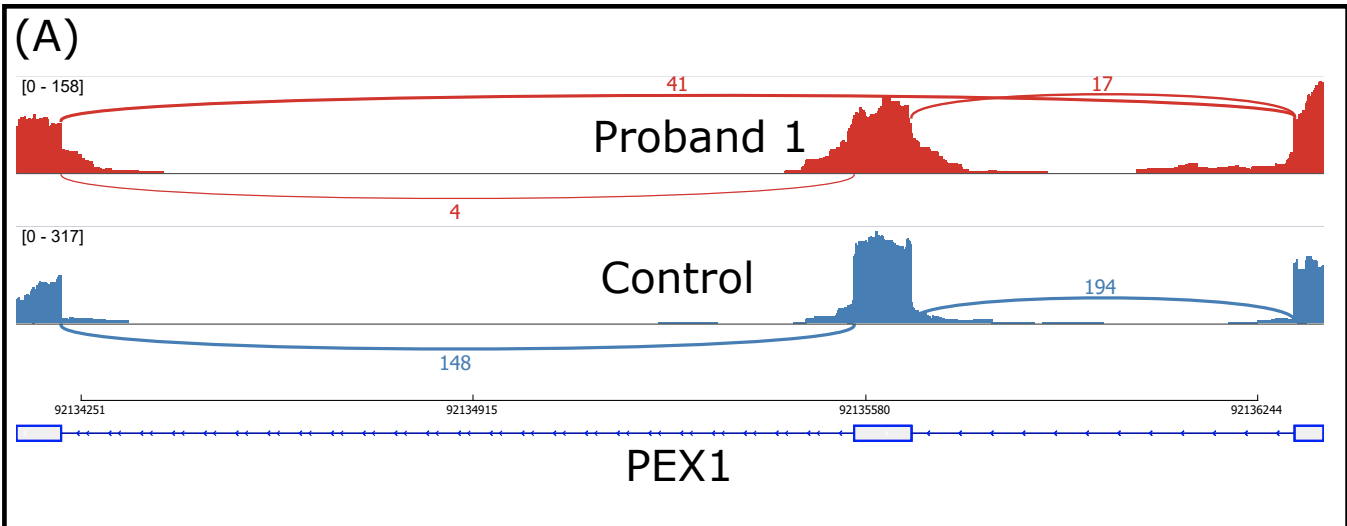

## Condensed Table of Skipping Event Results

| intron | effect size | pvalue |
| --- | --- | --- |
| 7:92134216:92135562:clu_9890_NA | -0.366394751 | 2.813559e-13 |
| 7:92135658:92136308:clu_9890_NA | -0.235675378 | 2.216743e-05 |
| 7:92134216:92136308:clu_9890_NA |  0.367876758 | 4.440892e-16 |



## Congrats on solving the case! Here is the case summary for this proband
Skipping of this exon was detected by blood whole RNA sequencing, which leads to an out-of-frame transcript that may be a substrate of nonsense-mediated decay. When examined in a sashimi plot (see above figure), a subset of the RNA-seq reads in this proband support abnormal splicing, suggesting a weakening of the splice donor. Further functional work is needed to determine if the c.1899A>T variant is causing disease in this family, however, it is clear that there is aberrant splicing of PEX1 exon 11.

### Note this skipping results in outlier expression analysis detecting loss of expression
In our earlier [outlier expression notebook](https://colab.research.google.com/drive/1dxSRoRZvStMAEjTVhhBghMzgrTIgX7yN?usp=sharing), this gene was found to have aberrantly low expression (note: due to our use of randomized labels, this proband appears as Proband9 in that notebook). This is consistent with (a) the loss of sequencing reads aligning to the skipped exons and (b) the nonsense-mediated decay that is expected on the resulting out-of-frame product.

---

##CHECKPOINT 2

---

# Let's investigate Proband 90's case in depth

Proband 90 has mild global developmental delay, distinctive features, short stature, cerebellar ectopia, Chiari I malformation, hyperreflexia, and attention-deficit hyperactivity disorder with no similarly affected family members. Trio WES identified a de novo intronic SNV (c.4026-9A>G) in EP300 (transcript NM_001429.3). This variant has been seen previously in an unrelated individual with Rubinstein-Taybi (Fergelot et al., 2016), but without any RNA or functional studies. SpliceAI (Jaganathan et al., 2019) predicts moderate loss of the exon 25 splice acceptor (DS_AL=0.3704, DP_AL=9) and a strong gain of a novel splice acceptor at c.4026-8 (DS_AG=0.9788, DP_AG=1) due to this variant. RNA-sequencing can provide a direct insight into the functional consequence of this variant at the mRNA level.

Below we subset our results to the relevant cluster and proband and print the outcome.

In [7]:
# Subset introns to this cluster view p-values and find highly significant ones
clu_rows <- grep("clu_23997_NA",row.names(df_intronP))
print("Pvalues")
print(df_intronP[clu_rows,"Proband90",drop=F])
sigrows <- df_intronP[clu_rows,"Proband90"] < 1e-3

# This is a big cluster, let's subset to signifigant introns, first by cluster then signifigance
df_meanSub <- df_mean[clu_rows,,drop=F]
df_testSub <- df_test[clu_rows,"Proband90",drop=F]
df_effSizeSub <- df_effSize[clu_rows,"Proband90",drop=F]
df_meanSub <- df_meanSub[sigrows,,drop=F]
df_testSub <- df_testSub[sigrows,,drop=F]
df_effSizeSub <- df_effSizeSub[sigrows,,drop=F]

# Now let's look at the fractional utilization (i.e., effect size) of the group
print("Group Mean Utilization")
print(df_meanSub)
print("Proband Fractional Utilization")
print(df_testSub)
print("Effect Sizes")
print(df_effSizeSub)

[1] "Pvalues"
                                     Proband90
22:41553412:41554380:clu_23997_NA 1.000000e+00
22:41553412:41554416:clu_23997_NA 4.145002e-02
22:41553412:41556646:clu_23997_NA 1.000000e+00
22:41553412:41560057:clu_23997_NA 1.000000e+00
22:41554504:41555700:clu_23997_NA 1.000000e+00
22:41554504:41555704:clu_23997_NA 8.576572e-01
22:41554504:41556616:clu_23997_NA 9.775328e-01
22:41554504:41556646:clu_23997_NA 7.662495e-02
22:41554504:41558727:clu_23997_NA 1.000000e+00
22:41554504:41560057:clu_23997_NA 1.000000e+00
22:41555821:41556646:clu_23997_NA 8.943261e-01
22:41556726:41558727:clu_23997_NA 5.117544e-01
22:41556726:41564453:clu_23997_NA 1.000000e+00
22:41558783:41560057:clu_23997_NA 4.674033e-03
22:41558783:41560074:clu_23997_NA 1.000000e+00
22:41558783:41562603:clu_23997_NA 1.000000e+00
22:41558787:41560057:clu_23997_NA 1.000000e+00
22:41560134:41562586:clu_23997_NA 1.000000e+00
22:41560134:41562603:clu_23997_NA 2.337260e-02
22:41560134:41564453:clu_23997_NA 3.537721e-01

## What do we find when going to IGV?

Note this is figure is from our bioinformatics manuscript where we relabeled Proband90 as Proband2.

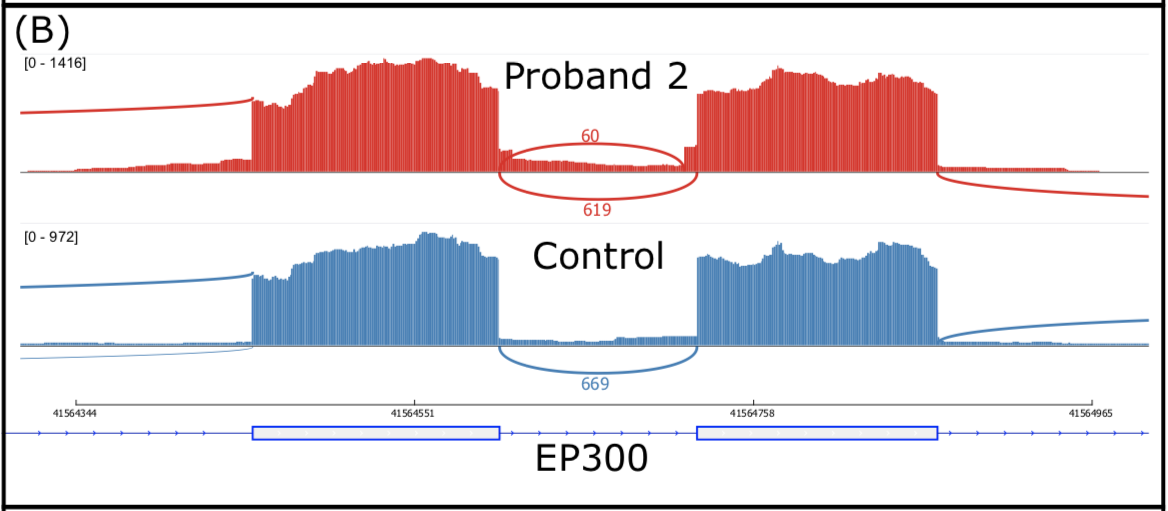

## Condensed Table of Frameshift Event Results

| intron | effect size | pvalue |
| --- | --- | --- |
| 22:41564603:41564717:clu_23997_NA | 0.01062559 | 1.629131e-08 |
| 22:41564603:41564725:clu_23997_NA | -0.06421800| 4.477491e-12 |



## Congrats on solving the case! Here is the case summary for this proband
As visualized in the above figure, the abnormal splicing detected by RNA sequencing of blood adds 8 nts to exon 25, causing a frame shift in the transcript. Observation of the variant-induced abnormal splicing provides additional evidence supporting this variant’s pathogenicity, which results in a genetic diagnosis of Rubinstein-Taybi for this patient. 

## Let's investigate Proband 100's clu_30973_NA introns in depth
Proband 100 has global developmental delay, focal epilepsy, autism spectrum disorder, and downbeat nystagmus with unaffected parents. Trio WES identified a de novo 4-bp intronic deletion (c.804-9_804-6delGTCT) in HNRNPU (transcript NM_031844.2) predicted to weaken the strength of the exon 3 splice acceptor. HNRNPU is associated with autosomal dominant early infantile epileptic encephalopathy 54 and is consistent with the proband’s clinical symptoms. RNA-sequencing can provide a direct insight into the functional consequence of this variant at the mRNA level.

Below we subset our results to the relevant cluster and proband and print the outcome.

In [8]:
# Subset introns to this cluster view p-values and find highly significant ones
clu_rows <- grep("clu_30973_NA",row.names(df_intronP))
print("Pvalues")
print(df_intronP[clu_rows,"Proband100",drop=F])

# Now let's look at the fractional utilization (i.e., effect size) of the group
print("Group Mean Utilization")
print(df_mean[clu_rows,,drop=F])
print("Proband Fractional Utilization")
print(df_test[clu_rows,"Proband100",drop=F])
print("Effect Sizes")
print(df_effSize[clu_rows,"Proband100",drop=F])

[1] "Pvalues"
                                     Proband100
1:245023776:245025763:clu_30973_NA 4.144380e-01
1:245023776:245026919:clu_30973_NA 1.940990e-02
1:245023776:245026976:clu_30973_NA 9.052135e-06
1:245025836:245025921:clu_30973_NA 1.970116e-01
1:245025836:245026919:clu_30973_NA 1.000000e+00
1:245025836:245026976:clu_30973_NA 9.632200e-01
1:245026032:245026919:clu_30973_NA 2.747556e-01
1:245026032:245026976:clu_30973_NA 7.896981e-01
[1] "Group Mean Utilization"
                              intron        mean
1 1:245023776:245025763:clu_30973_NA 0.414136840
2 1:245023776:245026919:clu_30973_NA 0.002400461
3 1:245023776:245026976:clu_30973_NA 0.002408938
4 1:245025836:245025921:clu_30973_NA 0.438520564
5 1:245025836:245026919:clu_30973_NA 0.002848628
6 1:245025836:245026976:clu_30973_NA 0.003725080
7 1:245026032:245026919:clu_30973_NA 0.050902278
8 1:245026032:245026976:clu_30973_NA 0.085057212
[1] "Proband Fractional Utilization"
                                    Proband100


## What do we find when going to IGV?

Note this is figure is from our bioinformatics manuscript where we relabeled Proband100 as Proband3.

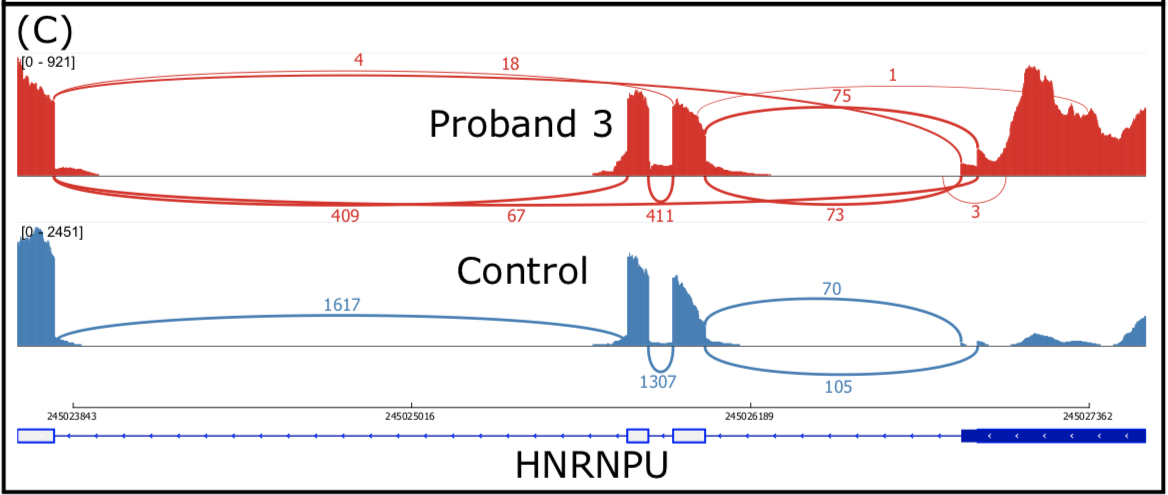

## Condensed Table of Skipping Event Results

| intron | effect size | pvalue |
| --- | --- | --- |
| 1:245023776:245026976:clu_30973_NA | 0.06432949 | 9.052135e-06 |


## Congrats on solving the case! Here is the case vignette for this proband
Blood RNA sequencing reveals skipping of both exons 2 and 3 (splicing from exon 1 to 4) as visualized in the above figure. This exon skipping event is predicted to lead to an in-frame transcript missing amino acid residues 231-293 and suspected to be disease causal in this individual.

## Real-world considerations
In each of these three vignettes, the proband in question had a suspected splicing variant in a gene of interest to the patient's phenotype. While this is reflective of some of the highest-yield cases for RNA-sequencing, it is not the norm for all patients in our rare-disease cohort. Therefore, to solve the other cases additional annotations and strategies must generally be employed. First, linking clusters to genes and corresponding DNA variants will be necessary. Next, we layer on annotations to the genes, such as pLI scores to indicate intolerance of the gene to loss of function. Finally, we can use knowledge of the phenotype to use tools such as PCAN to identify phenotypically relevant genes with aberrations. 

Ultimately, splicing is a highly noisy biological phenomena and so one can expect many significant clusters in any given proband, which will necessitate means of prioritizing the results. Absent any other means of prioritization, ranking based on lowest cluster p-values can give a means of "starting with the most aberrant" splicing events in your proband.

## Hope you enjoyed learning about outlier splicing detection!